# OF Regression Modeling 

Procedure:
- Loads `of_detailed` from `../data/processed/of_detailed.parquet`
- Engineers features:
  - `log_time`, `log_distance`, `log_weight`, `log_cube`, `log_quantity`
  - WorkCode 30
  - `Aisle` grouped
  - `Level` as categorical, 5+ combined
- Splits by 80/20
- Fits:
  1) Simple OLS: `log_time ~ log_distance + log_weight + WorkCode
  2) All-features OLS (all engineered features)
  3) Lasso
- Reports metrics, coefficients, and diagnostics plots.


In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

PATH = Path("../data/processed/of_detailed.parquet")

In [18]:
# Load oe_detailed
data = pd.read_parquet(PATH)

# Ensure Timestamp is datetime
data["Timestamp"] = pd.to_datetime(data.get("Timestamp"), errors="coerce")
data = data.dropna(subset=["Timestamp"]).copy()

print("data shape:", data.shape)
print("Timestamp range:", data["Timestamp"].min(), "->", data["Timestamp"].max())
data.head()

data shape: (126237, 30)
Timestamp range: 2025-09-06 03:31:35.690000 -> 2025-12-03 10:39:02.750000


,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Travel_Distance
0,PickPut,1001,20,8202054,4745,1,2025-11-10 10:16:39.143,73575,NaT,<NA>,...,<NA>,<NA>,<NA>,20,06,<NA>,<NA>,20|06|||,<NA>|<NA>|||,NaN
1,PickPut,1001,20,8202055,4745,1,2025-11-10 10:17:03.137,73575,2025-11-10 10:16:39.143,73575,...,6,5,2,20,06,20,06,20|06|||,20|06|||,0.0
2,PickPut,1001,20,8202056,4745,1,2025-11-10 10:17:24.510,73575,2025-11-10 10:17:03.137,73575,...,6,5,2,20,06,20,06,20|06|||,20|06|||,0.0
3,PickPut,1001,20,8202057,4745,1,2025-11-10 10:17:43.713,73575,2025-11-10 10:17:24.510,73575,...,6,5,2,20,06,20,06,20|06|||,20|06|||,0.0
4,PickPut,1001,20,8202058,63429,1,2025-11-10 10:19:58.057,1998192,2025-11-10 10:17:43.713,73575,...,6,5,2,20,46,20,06,20|46|||,20|06|||,322.0


In [19]:
# ---------- Feature engineering ----------
df = data.copy()

# Ensure numerics
for col in ["Time_Delta_sec", "Weight", "Cube", "Quantity"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Filter for log viability
df = df[
    (df["Time_Delta_sec"] > 0) &
    (df["Time_Delta_sec"] < 180) &
    (df["Travel_Distance"] >= 0) &
    (df["Weight"] > 0) &
    (df["Cube"] > 0) &
    (df["WorkCode"] == '30')
].copy()

# Logs
df["log_time"] = np.log(df["Time_Delta_sec"])
df["log_distance"] = np.log(df["Travel_Distance"])
df["log_weight"] = np.log(df["Weight"])
df["log_cube"] = np.log(df["Cube"])

df["log_distance_sq"] = df["log_distance"] ** 2

# log(quantity)
if "Quantity" in df.columns:
    if (df["Quantity"] <= 0).any():
        df["log_quantity"] = np.log1p(df["Quantity"])
    else:
        df["log_quantity"] = np.log(df["Quantity"])
else:
    df["log_quantity"] = np.nan

# WorkCode
df["WorkCode"] = df["WorkCode"].astype(str)

# Aisle to int first
df["Aisle"] = pd.to_numeric(df["Aisle"], errors="coerce").fillna(-1).astype(int)
# Aisle as new column
'''
def aisle_group(a):
    if 10 <= a < 20:
        return "10-19"
    elif 20 <= a < 30:
        return "20-29"
    elif 30 <= a < 39:
        return "30-38"
    elif 39 <= a < 43:
        return "39-42"
    else:
        return "other"
df["Aisle_group"] = df["Aisle"].apply(aisle_group)
'''
def aisle_group(a):
    if a in [70, 71, 72, 73, 74, 75]:
        return str(a)
    else:
        return "other"
df["Aisle_group"] = df["Aisle"].apply(aisle_group)

# Level categorical, 5 and above as "5+", rest as is
def level_group(l):
    if l in [5, 6, 7, 8, 9]:
        return "5+"
    else:
        return str(l)
df["Level_group"] = df["Level"].apply(level_group)

# Time of day (bucket)
df["hour"] = df["Timestamp"].dt.hour.astype(int)
def tod_bucket(h):
    if 6 <= h < 12:
        return "6-12"
    elif 12 <= h < 16:
        return "12-4"
    elif 16 <= h < 20:
        return "4-8"
    elif 20 <= h < 24:
        return "8-12"
    else:
        return "after_midnight"
df["time_of_day"] = df["hour"].apply(tod_bucket)

# Unit of Measure, 'EA', 'BX', 'PK', 'CA', CS, or group rest into other
def uom_group(u):
    if u in ['EA', 'BX', 'PK', 'CA', 'CS']:
        return u
    else:
        return "other"
df["UOM_group"] = df["UnitOfMeasure"].apply(uom_group)

# Day of week as levels
df["day_of_week"] = df["Timestamp"].dt.day_name()

# Add a feature same_aisle: 1 if Aisle and Prev_Aisle are the same, else 0
df["Prev_Aisle"] = pd.to_numeric(df["Prev_Aisle"], errors="coerce").fillna(-1).astype(int)
df["same_aisle"] = (df["Aisle"] == df["Prev_Aisle"]).astype(int)

# Add a feature if LocKey and Prev_LocKey are the same
df["same_lockey"] = (df["LocKey"] == df["PrevLocKey"]).astype(int)

# Add a feature if same lockey but differ in level
df["diff_level"] = ((df["LocKey"] == df["PrevLocKey"]) & (df["Level"] != df["Prev_Level"])).astype(int)

# Add a feature if ProductID in top 100 most common productid
product_counts = df["ProductID"].value_counts()
top_100_products = product_counts.head(100).index
df["top_100_product"] = df["ProductID"].isin(top_100_products).astype(int)

print("Engineered df shape:", df.shape)
df.head()


Engineered df shape: (20662, 46)


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Aisle_group,Level_group,hour,time_of_day,UOM_group,day_of_week,same_aisle,same_lockey,diff_level,top_100_product
698,PickPut,1001,30,8219618,40863,2,2025-11-12 11:30:03.867,4880955,2025-11-12 11:28:12.753,4613257,...,other,1,11,6-12,other,Wednesday,0,0,0,1
703,PickPut,1001,30,8219647,40863,10,2025-11-12 11:40:37.510,4880955,2025-11-12 11:38:10.387,4613257,...,other,1,11,6-12,other,Wednesday,0,0,0,1
1501,PickPut,1001,30,8335068,64351,2,2025-11-30 14:22:01.857,917994,2025-11-30 14:20:27.553,941040,...,75,3,14,12-4,other,Sunday,1,1,1,0
1999,PickPut,1002,30,8201910,114,2,2025-11-10 10:09:16.777,1089974,2025-11-10 10:09:12.687,1089974,...,71,1,10,6-12,other,Monday,1,1,0,1
2002,PickPut,1002,30,8201974,317,12,2025-11-10 10:12:35.427,1210250,2025-11-10 10:11:14.233,1001656,...,71,1,10,6-12,other,Monday,1,1,0,1


In [20]:
from sklearn.model_selection import train_test_split

# split into train and test, random 80/20 split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# DISPLAY DIMENSIONS
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16529, 46)
Test shape: (4133, 46)


In [21]:
# Helpers: design matrices, fit OLS(QR), evaluate, coefficient table, diagnostics

def build_Xy(df_in, feature_cols, cat_cols=None, drop_first=True, add_const=True):
    d = df_in.copy()
    y = d["log_time"].astype(float)
    X = d[feature_cols].copy()
    if cat_cols:
        X = pd.get_dummies(X, columns=cat_cols, drop_first=drop_first)
    X = X.replace([np.inf, -np.inf], np.nan).apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
    if add_const:
        X = sm.add_constant(X, has_constant="add")
    return X, y

def fit_ols_qr(X, y):
    return sm.OLS(y, X).fit(method="qr")

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

def eval_model(model, X_test, y_test, label="model"):
    pred_log = model.predict(X_test)

    # --- log scale metrics ---
    rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
    mae_log  = mean_absolute_error(y_test, pred_log)
    r2       = r2_score(y_test, pred_log)

    # --- convert back to original scale ---
    y_true = np.exp(y_test)
    pred   = np.exp(pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, pred))
    mae  = mean_absolute_error(y_true, pred)

    print(f"\n[{label}] Performance")
    print(f"Log scale  -> RMSE: {rmse_log:.4f} | MAE: {mae_log:.4f} | R²: {r2:.4f}")
    print(f"Original   -> RMSE: {rmse:.4f} sec | MAE: {mae:.4f} sec")

    return pred_log, pred, rmse_log, mae_log, rmse, mae, r2


def coef_table(model):
    return pd.DataFrame({
        "variable": model.params.index,
        "coefficient": model.params.values,
        "p_value": model.pvalues.values
    }).sort_values("p_value")

def diag_plots(y_true, y_pred, title_prefix=""):
    resid = y_true - y_pred
    fitted = y_pred
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(fitted, resid, alpha=0.3, s=15)
    axes[0].axhline(0, linestyle="--")
    axes[0].set_title(f"{title_prefix} Residuals vs Fitted")
    axes[0].set_xlabel("Fitted (log_time)")
    axes[0].set_ylabel("Residuals")

    axes[1].scatter(fitted, y_true, alpha=0.3, s=15)
    lims = [min(fitted.min(), y_true.min()), max(fitted.max(), y_true.max())]
    axes[1].plot(lims, lims, "r--")
    axes[1].set_title(f"{title_prefix} Actual vs Fitted")
    axes[1].set_xlabel("Fitted (log_time)")
    axes[1].set_ylabel("Actual (log_time)")

    sm.qqplot(resid, line="45", ax=axes[2])
    axes[2].set_title(f"{title_prefix} Q-Q Plot (Residuals)")

    plt.tight_layout()
    plt.show()


                            OLS Regression Results                            
Dep. Variable:               log_time   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     1864.
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:21:21   Log-Likelihood:                -21708.
No. Observations:               16529   AIC:                         4.342e+04
Df Residuals:                   16525   BIC:                         4.345e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.7747      0.017    158.667   

,variable,coefficient,p_value
0,const,2.774724,0.000000e+00
1,log_distance,0.308576,0.000000e+00
3,log_quantity,0.194583,2.241432e-275
2,log_weight,-0.035413,1.094642e-03


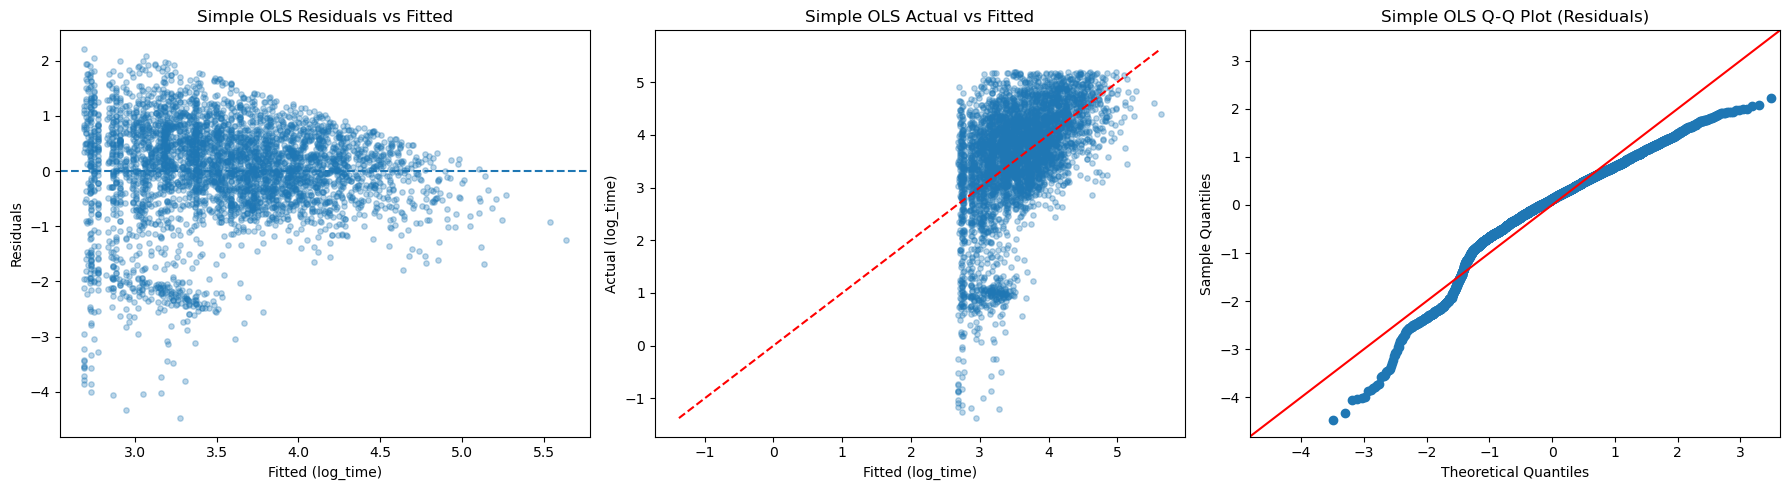

In [22]:
# ---------- Model 1: Simple OLS ----------
# log_time ~ log_distance + log_weight + log_quantity

simple_features = ["log_distance", "log_weight", "log_quantity"]
cat_cols_simple = []

X_train_s, y_train_s = build_Xy(train_df, simple_features, cat_cols=cat_cols_simple, drop_first=True, add_const=True)
X_test_s, y_test_s   = build_Xy(test_df,  simple_features, cat_cols=cat_cols_simple, drop_first=True, add_const=True)

X_test_s = X_test_s.reindex(columns=X_train_s.columns, fill_value=0)

model_simple = fit_ols_qr(X_train_s, y_train_s)
print(model_simple.summary())

pred_log_s, pred_s, rmse_log_s, mae_log_s, rmse_s, mae_s, r2_s = eval_model(model_simple, X_test_s, y_test_s, label="Simple OLS")

display(coef_table(model_simple).head(40))
diag_plots(y_test_s, pred_log_s, title_prefix="Simple OLS")


                            OLS Regression Results                            
Dep. Variable:               log_time   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     325.5
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:21:21   Log-Likelihood:                -20377.
No. Observations:               16529   AIC:                         4.081e+04
Df Residuals:                   16499   BIC:                         4.105e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

,variable,coefficient,p_value
0,const,3.431085,0.000000e+00
24,diff_level_1,1.055888,0.000000e+00
5,log_quantity,0.210360,0.000000e+00
22,same_aisle_1,-0.348350,1.383224e-16
23,same_lockey_1,-0.518582,6.503983e-16
14,Level_group_2,-0.131972,1.760128e-15
1,log_distance,0.298721,1.081591e-13
29,top_100_product_1,-0.101832,7.449041e-11
11,Aisle_group_other,-0.202653,6.283011e-10
9,Aisle_group_74,-0.120057,2.945360e-08


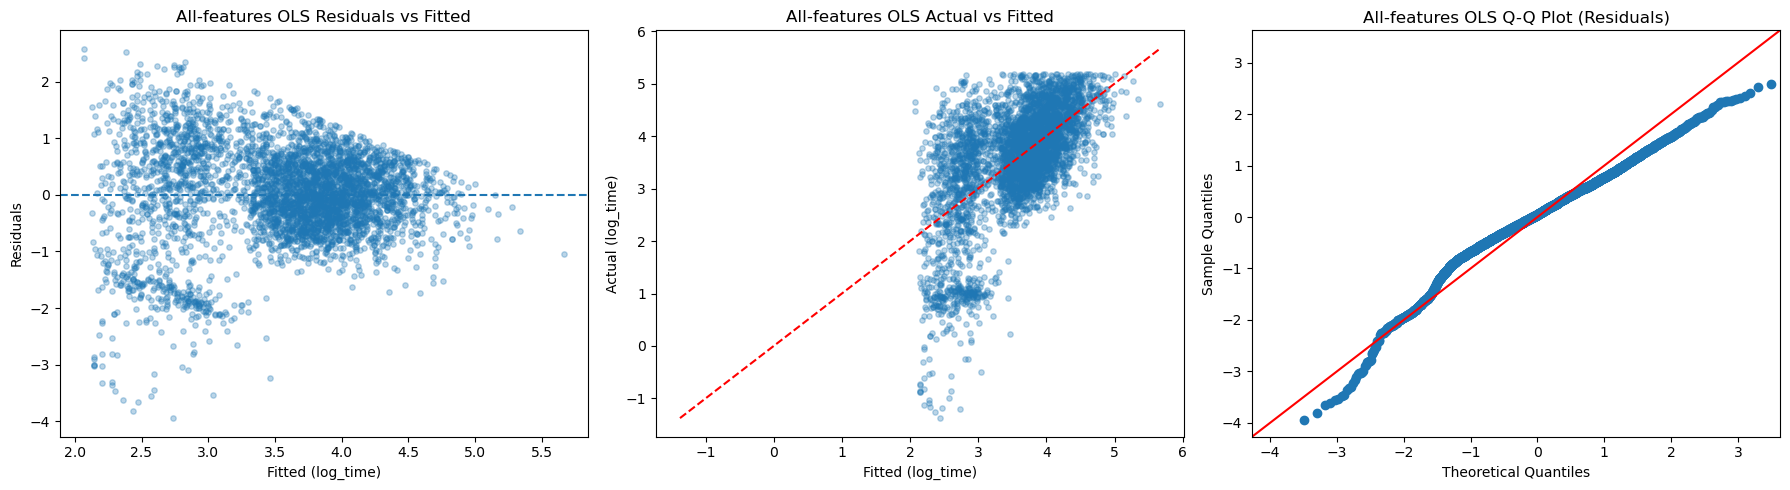

In [23]:
# ---------- Model 2: All-features OLS ----------
all_features = ["log_distance", "log_distance_sq", "log_weight", "log_cube", "log_quantity",
                "Aisle_group", "Level_group", "time_of_day", "same_aisle", "same_lockey", "diff_level", "UOM_group", "day_of_week", "top_100_product"]

cat_cols_all = ["Aisle_group", "Level_group", "time_of_day", "same_aisle", "same_lockey", "diff_level", "UOM_group", "day_of_week", "top_100_product"]

X_train_a, y_train_a = build_Xy(train_df, all_features, cat_cols=cat_cols_all, drop_first=True, add_const=True)
X_test_a, y_test_a   = build_Xy(test_df,  all_features, cat_cols=cat_cols_all, drop_first=True, add_const=True)

X_test_a = X_test_a.reindex(columns=X_train_a.columns, fill_value=0)

model_all = fit_ols_qr(X_train_a, y_train_a)
print(model_all.summary())

pred_log_a, pred_a, rmse_log_a, mae_log_a, rmse_a, mae_a, r2_a = eval_model(model_all, X_test_a, y_test_a, label="All-features OLS")

display(coef_table(model_all).head(60))
diag_plots(y_test_a, pred_log_a, title_prefix="All-features OLS")


In [24]:
# ---------- Model 3: Lasso regression ----------

features = [
    "log_distance",
    "log_distance_sq",
    "log_weight",
    "log_cube",
    "log_quantity",
    "Aisle_group",
    "Level_group",
    "time_of_day", "same_aisle", "same_lockey", "diff_level", "UOM_group", "day_of_week", "top_100_product"
]

cat_cols = ["Aisle_group", "Level_group", "time_of_day", "same_aisle", "same_lockey", "diff_level", "UOM_group", "day_of_week", "top_100_product"]

def build_X(df):
    X = df[features].copy()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X

X_train = build_X(train_df)
X_test  = build_X(test_df)

# align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df["log_time"].astype(float)
y_test  = test_df["log_time"].astype(float)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [26]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(
    cv=5,
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

lasso_cv.fit(X_train_scaled, y_train)

best_lambda = lasso_cv.alpha_
print("Best λ:", best_lambda)

Best λ: 0.0004575634469329819


In [27]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=best_lambda*5, max_iter=5000)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=np.float64(0.0022878172346649096), max_iter=5000)

In [28]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pred_lasso = lasso.predict(X_test_scaled)

r2_l = r2_score(y_test, pred_lasso)
rmse_log_l = np.sqrt(mean_squared_error(y_test, pred_lasso))
mae_log_l  = mean_absolute_error(y_test, pred_lasso)
rmse_l = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(pred_lasso)))
mae_l  = mean_absolute_error(np.exp(y_test), np.exp(pred_lasso))

print("Test RMSE:", rmse_l)
print("Test MAE:", mae_l)
print("Test R²:", r2_l)

Test RMSE: 34.49413838651917
Test MAE: 24.28918937456625
Test R²: 0.3646202351915563


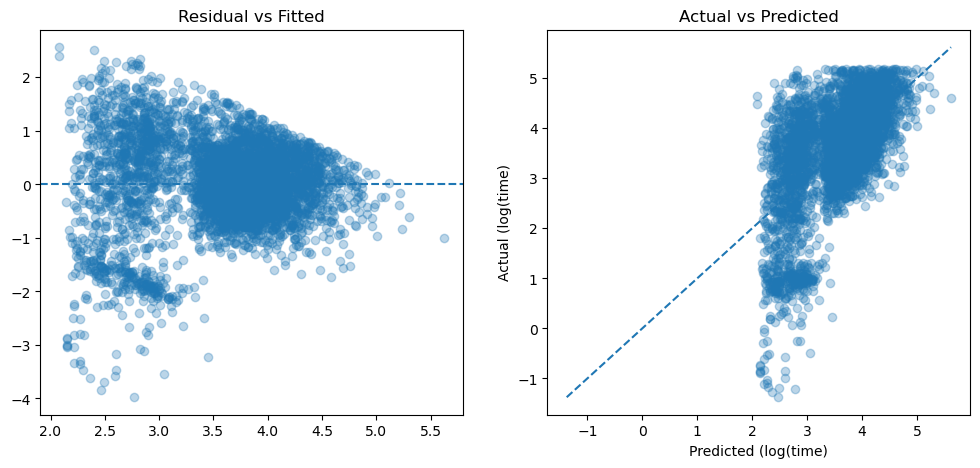

In [29]:
import matplotlib.pyplot as plt

resid = y_test - pred_lasso

fig, ax = plt.subplots(1,2, figsize=(12,5))

# residual vs fitted
ax[0].scatter(pred_lasso, resid, alpha=0.3)
ax[0].axhline(0, linestyle="--")
ax[0].set_title("Residual vs Fitted")

# actual vs predicted
ax[1].scatter(pred_lasso, y_test, alpha=0.3)
lims = [min(pred_lasso.min(), y_test.min()), max(pred_lasso.max(), y_test.max())]
ax[1].plot(lims, lims, "--")
ax[1].set_title("Actual vs Predicted")
ax[1].set_xlabel("Predicted (log(time)")
ax[1].set_ylabel("Actual (log(time)")

plt.show()


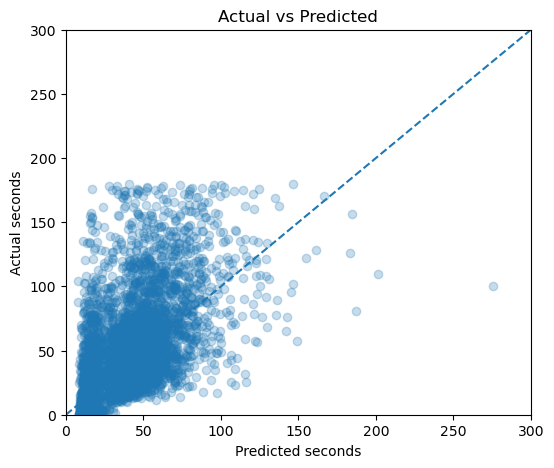

In [30]:
# Actual vs predicted on the original scale, limit window to 300 seconds for better visualization
lims = [0, 300]
pred_lasso_sec = np.exp(pred_lasso)
y_test_sec = np.exp(y_test)
plt.figure(figsize=(6,5))
plt.scatter(pred_lasso_sec, y_test_sec, alpha=0.25)
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims, "--")
plt.xlabel("Predicted seconds")
plt.ylabel("Actual seconds")
plt.title("Actual vs Predicted")
plt.show()

In [31]:
coef_table = (
    pd.DataFrame({
        "feature": X_train.columns,
        "coefficient": lasso.coef_
    })
    .sort_values("coefficient", key=abs, ascending=False)
)
selected = coef_table[coef_table["coefficient"] != 0]
print("Selected features:", len(selected))
display(selected)

Selected features: 26


,feature,coefficient
23,diff_level_1,0.360552
22,same_lockey_1,-0.321755
0,log_distance,0.320561
4,log_quantity,0.270974
21,same_aisle_1,-0.064249
13,Level_group_2,-0.054883
10,Aisle_group_other,-0.053422
28,top_100_product_1,-0.041405
8,Aisle_group_74,-0.034352
17,time_of_day_4-8,0.025324


In [32]:
# ---------- Model comparison ----------
summary = pd.DataFrame([
    {"Model": "Simple OLS", "r2": r2_s, "mae": mae_s, "rmse": rmse_s},
    {"Model": "All-features OLS", "r2": r2_a, "mae": mae_a, "rmse": rmse_a},
    {"Model": "Lasso", "r2": r2_l, "mae": mae_l, "rmse": rmse_l},
])

display(summary.round(4))

,Model,r2,mae,rmse
0,Simple OLS,0.2575,25.5981,36.2272
1,All-features OLS,0.3650,24.3049,34.4845
2,Lasso,0.3646,24.2892,34.4941
